# Multi-model keyword spotting evaluation

This notebook evaluates every model in `MODELS` on the same validation split and through the same batch-1 TFLite inference path. Keras entries are converted to float TFLite in memory; TFLite entries are loaded directly. It preserves the project metrics: argmax accuracy, wake-word TPR, FAR, false accepts, threshold sweep, and confusion matrices.

Notebook latency is experimental host-side TFLite model invocation only. It excludes audio preprocessing and post-processing, and must not be compared directly with the ESP32 system benchmark unless the measurement setup is explicitly matched.

## 1. Editable paths and model list

In [40]:
from pathlib import Path

# Change paths here when moving the project or evaluating another keyword.
PROJECT_ROOT = Path('/home/sanjeet/ai_workspace/KWS model/sih-2026')
MODELS_DIR = PROJECT_ROOT / 'models'
DATA_DIR = PROJECT_ROOT / 'data'
RESULTS_DIR = PROJECT_ROOT / 'results'

# Add or remove entries without changing the evaluation logic below.
MODELS = {
    'FP32': MODELS_DIR / 'marvin.float.tflite',
    'FP16': MODELS_DIR / 'marvin.fp16.tflite',
    'INT8': MODELS_DIR / 'marvin.int8.tflite',
}

# Optional architecture metadata. This is not used for inference.
ARCHITECTURE_METADATA_PATH = MODELS_DIR / 'marvin.keras'

# Optional embedded benchmark artifacts. These are measured on-device values,
# not estimates from the host TFLite interpreter.
EMBEDDED_BENCHMARKS = {
    'INT8': RESULTS_DIR / 'bench.json',
}
ESP32_ARENA_BUDGET_BYTES = 65 * 1024

# Evaluation and benchmark settings.
NOISE_CAP = 400
WAKE_THRESHOLD = None  # None uses shared.config.WAKE_SCORE_THRESHOLD.
THRESHOLDS = __import__('numpy').arange(0.30, 0.96, 0.05)
WARMUP_RUNS = 10
BENCHMARK_RUNS = 100

# Optional exports.
EXPORT_JSON = RESULTS_DIR / 'evaluation_all_models.json'
EXPORT_CSV = RESULTS_DIR / 'evaluation_all_models.csv'

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f'Project root does not exist: {PROJECT_ROOT}')
missing_models = {label: path for label, path in MODELS.items() if not path.exists()}
if missing_models:
    raise FileNotFoundError(f'Missing configured models: {missing_models}')
print(f'Project root: {PROJECT_ROOT}')
print('Configured models:')
for label, path in MODELS.items():
    print(f'  {label}: {path}')

Project root: /home/sanjeet/ai_workspace/KWS model/sih-2026
Configured models:
  FP32: /home/sanjeet/ai_workspace/KWS model/sih-2026/models/marvin.float.tflite
  FP16: /home/sanjeet/ai_workspace/KWS model/sih-2026/models/marvin.fp16.tflite
  INT8: /home/sanjeet/ai_workspace/KWS model/sih-2026/models/marvin.int8.tflite


## 2. Imports and project configuration

In [31]:
import json
import sys
import time
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score, confusion_matrix

sys.path.insert(0, str(PROJECT_ROOT))

from shared.config import KEYWORD, WAKE_SCORE_THRESHOLD
from shared.feature_spec import FEATURE_SHAPE
from training.model import N_CLASSES
from training.train import collect, wake_metrics

CLASS_NAMES = ['keyword', 'unknown', 'silence']
if N_CLASSES != len(CLASS_NAMES):
    raise ValueError(f'Expected {len(CLASS_NAMES)} classes, project reports {N_CLASSES}')
THRESHOLD = WAKE_SCORE_THRESHOLD if WAKE_THRESHOLD is None else float(WAKE_THRESHOLD)
print(f'Keyword: {KEYWORD}')
print(f'Feature shape: {FEATURE_SHAPE}')
print(f'Classes: {CLASS_NAMES}')
print(f'Wake threshold: {THRESHOLD:.2f}')

Keyword: marvin
Feature shape: (49, 20, 1)
Classes: ['keyword', 'unknown', 'silence']
Wake threshold: 0.52


## 3. Load one shared validation dataset

In [32]:
train_data, val_data, speakers, gsc_split = collect(
    KEYWORD,
    holdout_speaker=None,
    noise_cap=NOISE_CAP,
)
x_val, y_val, _ = val_data.arrays()

if x_val.ndim != 4 or tuple(x_val.shape[1:]) != tuple(FEATURE_SHAPE):
    raise ValueError(f'Unexpected validation shape: {x_val.shape}')
print(f'Validation samples: {len(x_val):,}')
print(f'Feature shape: {x_val.shape[1:]}')
print(f'Using GSC test split: {gsc_split}')
print(f'Class counts: {dict(zip(CLASS_NAMES, np.bincount(y_val, minlength=N_CLASSES)))}')

  loaded 2000 clips...
  loaded 3000 clips...
  loaded 4000 clips...
  loaded 6000 clips...
  loaded 7000 clips...
  loaded 8000 clips...
  loaded 9000 clips...
  loaded 10000 clips...
  loaded 11000 clips...
  loaded 12000 clips...
  loaded 13000 clips...
  loaded 14000 clips...
  loaded 15000 clips...
  loaded 16000 clips...
  loaded 17000 clips...
  loaded 18000 clips...
  loaded 19000 clips...
  loaded 20000 clips...
  loaded 21000 clips...
  loaded 22000 clips...
  loaded 23000 clips...
Validation samples: 11,164
Feature shape: (49, 20, 1)
Using GSC test split: True
Class counts: {'keyword': np.int64(195), 'unknown': np.int64(10810), 'silence': np.int64(159)}


## 4. Generic TFLite inference and measurement helpers

In [41]:
def _quantization_info(tensor: dict[str, Any]) -> dict[str, Any]:
    params = tensor.get('quantization_parameters', {})
    scales = np.asarray(params.get('scales', []), dtype=np.float32)
    zero_points = np.asarray(params.get('zero_points', []), dtype=np.int64)
    axes = params.get('quantized_dimension', 0)
    return {
        'scales': scales,
        'zero_points': zero_points,
        'quantized_dimension': axes,
    }

def _quantize_input(value: np.ndarray, tensor: dict[str, Any]) -> np.ndarray:
    dtype = tensor['dtype']
    if not np.issubdtype(dtype, np.integer):
        return value.astype(dtype, copy=False)
    info = _quantization_info(tensor)
    scales, zero_points = info['scales'], info['zero_points']
    if len(scales) != 1 or len(zero_points) != 1 or scales[0] == 0:
        raise ValueError(f'Unsupported input quantization for {dtype}: {info}')
    limits = np.iinfo(dtype)
    quantized = np.rint(value / scales[0] + zero_points[0])
    return np.clip(quantized, limits.min, limits.max).astype(dtype)

def _dequantize_output(value: np.ndarray, tensor: dict[str, Any]) -> np.ndarray:
    if not np.issubdtype(tensor['dtype'], np.integer):
        return value.astype(np.float32, copy=False)
    info = _quantization_info(tensor)
    scales, zero_points = info['scales'], info['zero_points']
    if len(scales) != 1 or len(zero_points) != 1 or scales[0] == 0:
        raise ValueError(f'Unsupported output quantization for {tensor["dtype"]}: {info}')
    return (value.astype(np.float32) - zero_points[0]) * scales[0]

def _tensor_summary(tensor: dict[str, Any]) -> dict[str, Any]:
    info = _quantization_info(tensor)
    return {
        'dtype': np.dtype(tensor['dtype']).name,
        'shape': [int(value) for value in tensor['shape']],
        'quantization_scales': info['scales'].tolist(),
        'quantization_zero_points': info['zero_points'].tolist(),
        'quantized_dimension': int(info['quantized_dimension']),
    }

def _tensor_memory_bytes(interpreter: tf.lite.Interpreter) -> int:
    total = 0
    for tensor in interpreter.get_tensor_details():
        shape = np.asarray(tensor['shape'], dtype=np.int64)
        if np.any(shape < 0):
            continue
        total += int(np.prod(shape, dtype=np.int64)) * np.dtype(tensor['dtype']).itemsize
    return total

def _embedded_memory(label: str) -> dict[str, Any]:
    benchmark_path = EMBEDDED_BENCHMARKS.get(label)
    if benchmark_path is None or not benchmark_path.exists():
        return {
            'arena_used_bytes': None,
            'arena_budget_bytes': ESP32_ARENA_BUDGET_BYTES,
            'arena_headroom_bytes': None,
            'arena_status': 'not measured',
            'arena_source': None,
        }
    payload = json.loads(benchmark_path.read_text())
    bench = payload.get('bench', {})
    used = bench.get('arena_used')
    budget = bench.get('arena_bytes', ESP32_ARENA_BUDGET_BYTES)
    if used is None:
        return {
            'arena_used_bytes': None,
            'arena_budget_bytes': int(budget),
            'arena_headroom_bytes': None,
            'arena_status': 'not measured',
            'arena_source': str(benchmark_path),
        }
    used = int(used)
    budget = int(budget)
    return {
        'arena_used_bytes': used,
        'arena_budget_bytes': budget,
        'arena_headroom_bytes': budget - used,
        'arena_status': 'within budget' if used <= budget else 'exceeds budget',
        'arena_source': str(benchmark_path),
    }

def _invoke_one(interpreter: tf.lite.Interpreter, input_tensor: dict[str, Any], output_tensor: dict[str, Any], sample: np.ndarray) -> np.ndarray:
    interpreter.set_tensor(input_tensor['index'], _quantize_input(sample[None, ...], input_tensor))
    interpreter.invoke()
    return _dequantize_output(interpreter.get_tensor(output_tensor['index']), output_tensor)[0]

def _latency_stats(milliseconds: list[float]) -> dict[str, float]:
    values = np.asarray(milliseconds, dtype=np.float64)
    return {
        'mean_ms': float(values.mean()),
        'median_ms': float(np.median(values)),
        'p95_ms': float(np.percentile(values, 95)),
        'p99_ms': float(np.percentile(values, 99)),
        'min_ms': float(values.min()),
        'max_ms': float(values.max()),
    }

## 5. Generic evaluation function

In [42]:
def evaluate_variant(label: str, model_path: Path) -> dict[str, Any]:
    if model_path.suffix.lower() in {'.keras', '.h5', '.hdf5'}:
        keras_model = tf.keras.models.load_model(model_path, compile=False)
        converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
        tflite_bytes = converter.convert()
        interpreter = tf.lite.Interpreter(model_content=tflite_bytes)
        runtime_type = 'Keras converted to float TFLite in memory'
    else:
        interpreter = tf.lite.Interpreter(model_path=str(model_path))
        runtime_type = 'TFLite file'
    interpreter.allocate_tensors()
    input_tensor = interpreter.get_input_details()[0]
    output_tensor = interpreter.get_output_details()[0]
    expected_shape = [1, *FEATURE_SHAPE]
    if list(input_tensor['shape']) != expected_shape:
        raise ValueError(f"{label}: expected input {expected_shape}, got {input_tensor['shape']}")
    if int(np.prod(output_tensor['shape'])) != N_CLASSES:
        raise ValueError(f"{label}: expected {N_CLASSES} outputs, got {output_tensor['shape']}")

    tensor_memory_bytes = _tensor_memory_bytes(interpreter)
    embedded_memory = _embedded_memory(label)

    for sample in x_val[:WARMUP_RUNS]:
        _invoke_one(interpreter, input_tensor, output_tensor, sample)

    probabilities = np.empty((len(x_val), N_CLASSES), dtype=np.float32)
    for index, sample in enumerate(x_val):
        probabilities[index] = _invoke_one(interpreter, input_tensor, output_tensor, sample)
    predictions = probabilities.argmax(axis=1)

    latency_ms = []
    benchmark_sample = x_val[0]
    for _ in range(BENCHMARK_RUNS):
        start = time.perf_counter_ns()
        _invoke_one(interpreter, input_tensor, output_tensor, benchmark_sample)
        latency_ms.append((time.perf_counter_ns() - start) / 1_000_000)

    wake = wake_metrics(probabilities, y_val, THRESHOLD)
    sweep = []
    for threshold in THRESHOLDS:
        current = wake_metrics(probabilities, y_val, float(threshold))
        sweep.append({
            'threshold': float(threshold),
            'tpr': current['tpr'],
            'far': current['far'],
            'false_accepts': current['false_accepts'],
        })

    metadata = {}
    if ARCHITECTURE_METADATA_PATH.exists():
        keras_model = tf.keras.models.load_model(ARCHITECTURE_METADATA_PATH, compile=False)
        metadata = {
            'parameters_total': int(keras_model.count_params()),
            'parameters_trainable': int(np.sum([np.prod(v.shape) for v in keras_model.trainable_weights])),
            'parameters_non_trainable': int(np.sum([np.prod(v.shape) for v in keras_model.non_trainable_weights])),
            'architecture_metadata_source': str(ARCHITECTURE_METADATA_PATH),
        }

    return {
        'label': label,
        'path': str(model_path),
        'model_size_bytes': int(model_path.stat().st_size),
        'runtime_type': runtime_type,
        'accuracy': float(accuracy_score(y_val, predictions)),
        'tpr': wake['tpr'],
        'far': wake['far'],
        'false_accepts': wake['false_accepts'],
        'threshold': wake['threshold'],
        'n_keyword': wake['n_keyword'],
        'n_negative': wake['n_negative'],
        'far_by_class': wake['far_by_class'],
        'confusion_matrix': confusion_matrix(y_val, predictions, labels=list(range(N_CLASSES))).tolist(),
        'threshold_sweep': sweep,
        'input': _tensor_summary(input_tensor),
        'output': _tensor_summary(output_tensor),
        'tensor_memory_bytes': tensor_memory_bytes,
        **embedded_memory,
        'latency': _latency_stats(latency_ms),
        'latency_method': 'host-side TFLite model invocation only; batch size 1; preprocessing/post-processing excluded',
        **metadata,
    }

## 6. Evaluate every configured model

In [43]:
RESULTS = {}
for label, model_path in MODELS.items():
    print(f'Evaluating {label}: {model_path.name}')
    RESULTS[label] = evaluate_variant(label, model_path)
    result = RESULTS[label]
    print(
        f"  accuracy={result['accuracy']:.4f}  "
        f"TPR={result['tpr']:.4f}  FAR={result['far']:.4f}  "
        f"mean latency={result['latency']['mean_ms']:.3f} ms"
    )
print(f'Completed {len(RESULTS)} model evaluations.')

Evaluating FP32: marvin.float.tflite


/home/sanjeet/ai_workspace/KWS model/sih-2026/.venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  accuracy=0.9874  TPR=0.8410  FAR=0.0063  mean latency=0.158 ms
Evaluating FP16: marvin.fp16.tflite


/home/sanjeet/ai_workspace/KWS model/sih-2026/.venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  accuracy=0.9874  TPR=0.8410  FAR=0.0063  mean latency=0.159 ms
Evaluating INT8: marvin.int8.tflite


/home/sanjeet/ai_workspace/KWS model/sih-2026/.venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  accuracy=0.9875  TPR=0.8410  FAR=0.0066  mean latency=0.386 ms
Completed 3 model evaluations.


## 7. Consolidated comparison table

In [45]:
def _shape_text(value: list[int]) -> str:
    return 'x'.join(str(item) for item in value)

def _kb(value: int | None) -> float:
    return value / 1024 if value is not None else np.nan

table_rows = []
for label, result in RESULTS.items():
    row = {
        'Model': label,
        'Accuracy (%)': result['accuracy'] * 100,
        'TPR (%)': result['tpr'] * 100,
        'FAR (%)': result['far'] * 100,
        'False accepts': result['false_accepts'],
        'Threshold': result['threshold'],
        'Model size (KB)': result['model_size_bytes'] / 1024,
        'Runtime': result['runtime_type'],
        'Parameters': result.get('parameters_total', np.nan),
        'Host tensor buffers (KiB)': _kb(result['tensor_memory_bytes']),
        'ESP32 arena used (KiB)': _kb(result['arena_used_bytes']),
        # 'ESP32 arena budget (KiB)': _kb(result['arena_budget_bytes']),
        'ESP32 arena headroom (KiB)': _kb(result['arena_headroom_bytes']),
        # 'ESP32 arena status': result['arena_status'],
        'Mean latency (ms)': result['latency']['mean_ms'],
        'Median latency (ms)': result['latency']['median_ms'],
        'P95 latency (ms)': result['latency']['p95_ms'],
        'P99 latency (ms)': result['latency']['p99_ms'],
        'Min latency (ms)': result['latency']['min_ms'],
        'Max latency (ms)': result['latency']['max_ms'],
    }
    table_rows.append(row)

comparison_df = pd.DataFrame(table_rows)
display(
    comparison_df.style
    .format({
        'Accuracy (%)': '{:.2f}', 'TPR (%)': '{:.2f}', 'FAR (%)': '{:.3f}',
        'Threshold': '{:.2f}', 'Model size (KB)': '{:.2f}',
        'Host tensor buffers (KiB)': '{:.2f}',
        'ESP32 arena used (KiB)': '{:.2f}',
        # 'ESP32 arena budget (KiB)': '{:.2f}',
        'ESP32 arena headroom (KiB)': '{:.2f}',
        'Mean latency (ms)': '{:.3f}', 'Median latency (ms)': '{:.3f}',
        'P95 latency (ms)': '{:.3f}', 'P99 latency (ms)': '{:.3f}',
        'Min latency (ms)': '{:.3f}', 'Max latency (ms)': '{:.3f}',
    })
    .hide(axis='index')
)

Model,Accuracy (%),TPR (%),FAR (%),False accepts,Threshold,Model size (KB),Runtime,Parameters,Host tensor buffers (KiB),ESP32 arena used (KiB),ESP32 arena headroom (KiB),Mean latency (ms),Median latency (ms),P95 latency (ms),P99 latency (ms),Min latency (ms),Max latency (ms)
FP32,98.74,84.10,0.630,69,0.52,95.91,TFLite file,23747,902.62,nan,nan,0.158,0.143,0.213,0.283,0.141,0.429
FP16,98.74,84.10,0.630,69,0.52,57.69,TFLite file,23747,945.63,nan,nan,0.159,0.143,0.201,0.278,0.141,0.374
INT8,98.75,84.10,0.660,72,0.52,47.74,TFLite file,23747,227.36,55.81,8.19,0.386,0.363,0.514,0.672,0.333,0.675


## Memory and latency interpretation

- **Model size** is the size of the configured `.tflite` file. It is flash/storage usage, not RAM.
- **Host tensor buffers** is the sum of tensor buffers reported by the host interpreter. It includes model tensors and is useful for comparing graph footprints, but it is not an ESP32 tensor-arena measurement.
- **ESP32 arena usage** is shown only when a matching device benchmark artifact is configured. It is the measured TFLM arena usage and is the relevant value for the embedded RAM budget.
- The supplied `results/bench.json` reports INT8 usage of `57,148 / 65,536` bytes, or `55.81 / 64.00 KiB`, leaving `8.19 KiB` headroom. The notebook target setting is 65 KiB, so this measurement is also below that target.
- No equivalent float/FP16 ESP32 arena measurement is silently inferred; those variants require their own firmware benchmark.
- Host latency includes the Python/TFLite invocation path and should not be treated as embedded INT8 latency.

## 8. Confusion matrices

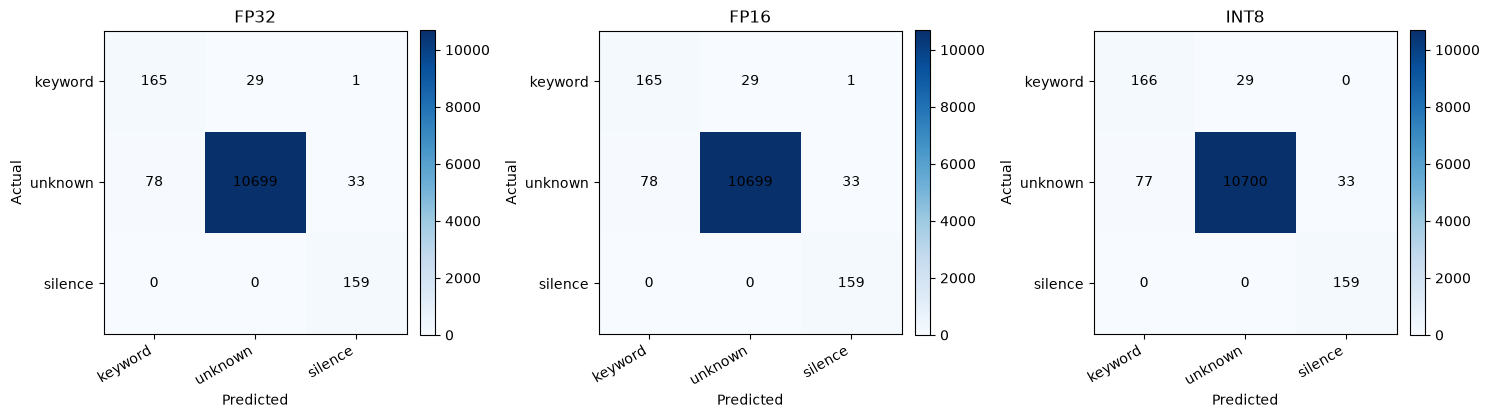

In [26]:
n_models = len(RESULTS)
n_columns = min(3, max(1, n_models))
n_rows = (n_models + n_columns - 1) // n_columns
fig, axes = plt.subplots(n_rows, n_columns, figsize=(5 * n_columns, 4.5 * n_rows), squeeze=False)
for axis, (label, result) in zip(axes.flat, RESULTS.items()):
    matrix = np.asarray(result['confusion_matrix'])
    image = axis.imshow(matrix, cmap='Blues')
    axis.set_title(label)
    axis.set_xticks(range(N_CLASSES), CLASS_NAMES, rotation=30, ha='right')
    axis.set_yticks(range(N_CLASSES), CLASS_NAMES)
    axis.set_xlabel('Predicted')
    axis.set_ylabel('Actual')
    for row_index in range(N_CLASSES):
        for column_index in range(N_CLASSES):
            axis.text(column_index, row_index, matrix[row_index, column_index], ha='center', va='center')
    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
for axis in axes.flat[n_models:]:
    axis.set_visible(False)
plt.tight_layout()
plt.show()

## 9. Threshold trade-off comparison

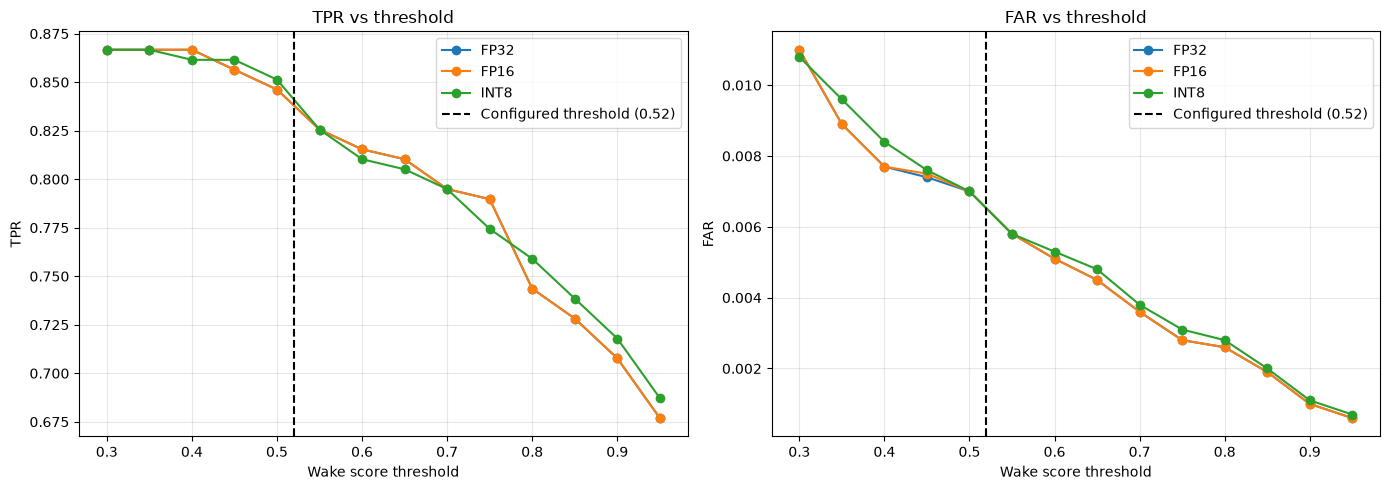

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for label, result in RESULTS.items():
    sweep = pd.DataFrame(result['threshold_sweep'])
    axes[0].plot(sweep['threshold'], sweep['tpr'], marker='o', label=label)
    axes[1].plot(sweep['threshold'], sweep['far'], marker='o', label=label)
for axis, metric, title in zip(axes, ['tpr', 'far'], ['TPR vs threshold', 'FAR vs threshold']):
    axis.axvline(THRESHOLD, color='black', linestyle='--', label=f'Configured threshold ({THRESHOLD:.2f})')
    axis.set_xlabel('Wake score threshold')
    axis.set_ylabel(metric.upper())
    axis.set_title(title)
    axis.grid(True, alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()

## 10. Export results

In [39]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
export_payload = {
    'methodology': {
        'keyword': KEYWORD,
        'validation_samples': int(len(y_val)),
        'feature_shape': list(FEATURE_SHAPE),
        'classes': CLASS_NAMES,
        'gsc_test_split': bool(gsc_split),
        'noise_cap': NOISE_CAP,
        'threshold': THRESHOLD,
        'thresholds_swept': [float(value) for value in THRESHOLDS],
        'warmup_runs': WARMUP_RUNS,
        'benchmark_runs': BENCHMARK_RUNS,
        'latency_scope': 'host-side TFLite model invocation only; batch size 1; preprocessing/post-processing excluded',
        'esp32_arena_budget_bytes': ESP32_ARENA_BUDGET_BYTES,
        'embedded_benchmarks': {label: str(path) for label, path in EMBEDDED_BENCHMARKS.items()},
    },
    'models': RESULTS,
}
EXPORT_JSON.write_text(json.dumps(export_payload, indent=2))
comparison_df.to_csv(EXPORT_CSV, index=False)
print(f'Wrote {EXPORT_JSON}')
print(f'Wrote {EXPORT_CSV}')

Wrote /home/sanjeet/ai_workspace/KWS model/sih-2026/results/evaluation_all_models.json
Wrote /home/sanjeet/ai_workspace/KWS model/sih-2026/results/evaluation_all_models.csv


## Interpretation notes

- Accuracy, TPR, FAR, false accepts, confusion matrices, and threshold sweeps are experimentally calculated from the same validation tensors for every configured model.
- Model size is measured from each configured `.tflite` file and represents flash/storage usage.
- Parameter count is architecture metadata loaded from the optional Keras source and is not inferred from quantized file size.
- Tensor memory lower bound is calculated from the allocated TFLite tensor metadata; it is a lower bound, not a complete ESP32 arena prediction.
- ESP32 arena usage is included only when a matching device benchmark artifact is configured. The current INT8 artifact reports measured usage against the 65 KiB budget.
- Latency is host-side TFLite invocation only, measured with the same batch size, warmups, and repetitions for every model.
- Audio feature extraction, microphone capture, smoothing, debounce, and idle CPU are not included in model-only latency.

In [29]:
import keras
class KeywordRecall(keras.metrics.Metric):

    def __init__(self, name="keyword_recall", **kwargs):
        super().__init__(name=name, **kwargs)
        self.tp = self.add_weight(name="tp", initializer="zeros")
        self.fn = self.add_weight(name="fn", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.argmax(y_pred, axis=-1, output_type=tf.int32)

        true_keyword = tf.equal(y_true, 0)
        predicted_keyword = tf.equal(y_pred, 0)

        tp = tf.reduce_sum(
            tf.cast(true_keyword & predicted_keyword, self.dtype)
        )
        fn = tf.reduce_sum(
            tf.cast(true_keyword & ~predicted_keyword, self.dtype)
        )

        self.tp.assign_add(tp)
        self.fn.assign_add(fn)

    def result(self):
        return self.tp / (self.tp + self.fn + keras.backend.epsilon())

    def reset_state(self):
        self.tp.assign(0)
        self.fn.assign(0)


